Hola **Jesus**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivos
orders    = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog   = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
print('=== ORDERS ===')
print(f'Shape: {orders.shape}')
display(orders.head(3))
display(orders.dtypes.rename('dtype'))
display(orders.isnull().sum().rename('nulos'))

print('\n=== CATALOG ===')
print(f'Shape: {catalog.shape}')
display(catalog.head())

print('\n=== MARKETING ===')
print(f'Shape: {marketing.shape}')
display(marketing.head(3))
display(marketing.isnull().sum().rename('nulos'))

=== ORDERS ===
Shape: (25100, 12)


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99


id_pedido              object
id_usuario             object
fecha_hora_pedido      object
pais                   object
dispositivo            object
fuente_referencia      object
nombre_producto        object
categoria_producto     object
cantidad              float64
precio_unitario       float64
monto_descuento       float64
monto_total           float64
Name: dtype, dtype: object

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
Name: nulos, dtype: int64


=== CATALOG ===
Shape: (7, 4)


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"



=== MARKETING ===
Shape: (1620, 5)


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01


fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
Name: nulos, dtype: int64

In [4]:
print(f'Filas antes: {len(orders)}')
orders = orders.drop_duplicates()
print(f'Filas despues de drop_duplicates: {len(orders)}')

orders['fecha_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')
print(f'\nRango de fechas: {orders["fecha_pedido"].min()} → {orders["fecha_pedido"].max()}')

orders = orders.dropna(subset=['cantidad', 'precio_unitario', 'monto_total'])
print(f'Filas tras eliminar nulos en columnas clave: {len(orders)}')

orders['pais']               = orders['pais'].fillna('Unknown')
orders['dispositivo']        = orders['dispositivo'].fillna('Unknown')
orders['fuente_referencia']  = orders['fuente_referencia'].fillna('Unknown')
orders['nombre_producto']    = orders['nombre_producto'].fillna('Unknown')
orders['categoria_producto'] = orders['categoria_producto'].fillna('Unknown')

orders['categoria_producto'] = orders['categoria_producto'].str.replace('Electronica', 'Electrónica', regex=False)

print(f'\nPrecios negativos: {(orders["precio_unitario"] < 0).sum()}')
print(f'Montos negativos:  {(orders["monto_total"] < 0).sum()}')
print('\nOrders limpio. Shape:', orders.shape)

Filas antes: 25100
Filas despues de drop_duplicates: 25000

Rango de fechas: 2025-01-01 00:00:00 → 2025-06-30 00:00:00
Filas tras eliminar nulos en columnas clave: 24950

Precios negativos: 0
Montos negativos:  4

Orders limpio. Shape: (24950, 13)


In [5]:
orders = orders[orders['monto_total'] >= 0]
print('Filas tras eliminar montos negativos:', len(orders))

Filas tras eliminar montos negativos: 24946


---

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecha la revisión inicial de los datos. Siempre es importante realizar una revisión general de los mismos para entender que es lo que se debe hacer en la parte de procesamiento previo al análisis cómo tal.
</div>

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
print(f'Duplicados: {catalog.duplicated().sum()}')
print(f'Nulos:\n{catalog.isnull().sum()}')
print('\nCatalog limpio. Shape:', catalog.shape)
display(catalog)

Duplicados: 0
Nulos:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Catalog limpio. Shape: (7, 4)


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [7]:
print(f'Duplicados: {marketing.duplicated().sum()}')
print(f'\nNulos antes:\n{marketing.isnull().sum()}')

marketing['canal'] = marketing['canal'].fillna('unknown')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')

print(f'\nGastos negativos: {(marketing["gasto"] < 0).sum()}')
print('\nMarketing limpio. Shape:', marketing.shape)

Duplicados: 0

Nulos antes:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

Gastos negativos: 0

Marketing limpio. Shape: (1620, 5)


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [8]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [9]:
# Revenue total
revenue_total = orders['monto_total'].sum()

# Costo total: unir orders con catalog para obtener costo_unitario por producto
orders_cost = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
orders_cost['costo_linea'] = orders_cost['costo_unitario'] * orders_cost['cantidad']
costo_total = orders_cost['costo_linea'].sum()

# Inversion total en marketing
marketing_total = marketing['gasto'].sum()

# Profit
profit = revenue_total - costo_total - marketing_total

print('RENTABILIDAD DEL NEGOCIO')
print('=' * 40)
print(f'Revenue total:          ${revenue_total:>15,.2f}')
print(f'Costo total:            ${costo_total:>15,.2f}')
print(f'Inversion en marketing: ${marketing_total:>15,.2f}')
print('-' * 40)
print(f'Profit:                 ${profit:>15,.2f}')

margen = profit / revenue_total * 100
print(f'\nEl negocio es rentable. Margen de profit: {margen:.1f}%')

RENTABILIDAD DEL NEGOCIO
Revenue total:          $  51,966,981.56
Costo total:            $  43,124,069.01
Inversion en marketing: $   2,871,843.53
----------------------------------------
Profit:                 $   5,971,069.02

El negocio es rentable. Margen de profit: 11.5%


## Interpretacion de KPIs y graficas

**Rentabilidad del negocio:**
El negocio genera un Revenue total de 51.97M con un Costo de producto de 43.12M
y una Inversion en marketing de 2.87M. El Profit resultante es de 5.97M,
lo que representa un margen del 11.5%. El negocio es rentable aunque el margen es ajustado,
lo que indica que optimizar costos o incrementar el ticket promedio tendria un impacto directo en la rentabilidad.

**Unidades vendidas por producto:**
Laptop-Gaming-16GB domina ampliamente las ventas con mas de 140,000 unidades vendidas,
muy por encima del resto de productos que se mantienen entre 4,000 y 6,500 unidades.
Esto indica una alta concentracion de ventas en un solo producto, lo que representa
un riesgo si hay problemas de abastecimiento o si el producto pierde demanda.

**Gasto en marketing por canal:**
Los canales social, organic y paid_search tienen una inversion similar (860K-918K cada uno),
lo que sugiere una estrategia de marketing equilibrada. El canal "unknown" representa
177K de inversion sin clasificar que deberia revisarse para reclasificarse correctamente.

In [10]:
# Ticket promedio por orden
ticket_promedio = orders['monto_total'].mean()

# Cantidad promedio de productos por orden
cantidad_promedio = orders['cantidad'].mean()

# Producto mas vendido por unidades
ventas_producto = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
producto_top = ventas_producto.index[0]

# Gasto en marketing por canal
gasto_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False).reset_index()

print('COMPORTAMIENTO DE VENTAS')
print('=' * 40)
print(f'Ticket promedio por orden:            ${ticket_promedio:,.2f}')
print(f'Cantidad promedio de productos/orden: {cantidad_promedio:.2f}')
print(f'Producto mas vendido:                 {producto_top}')

print('\nGASTO EN MARKETING POR CANAL')
print(gasto_canal.to_string(index=False))

COMPORTAMIENTO DE VENTAS
Ticket promedio por orden:            $2,083.18
Cantidad promedio de productos/orden: 7.12
Producto mas vendido:                 Laptop-Gaming-16GB

GASTO EN MARKETING POR CANAL
      canal     gasto
     social 918043.21
    organic 913533.01
paid_search 863088.21
    unknown 177179.10


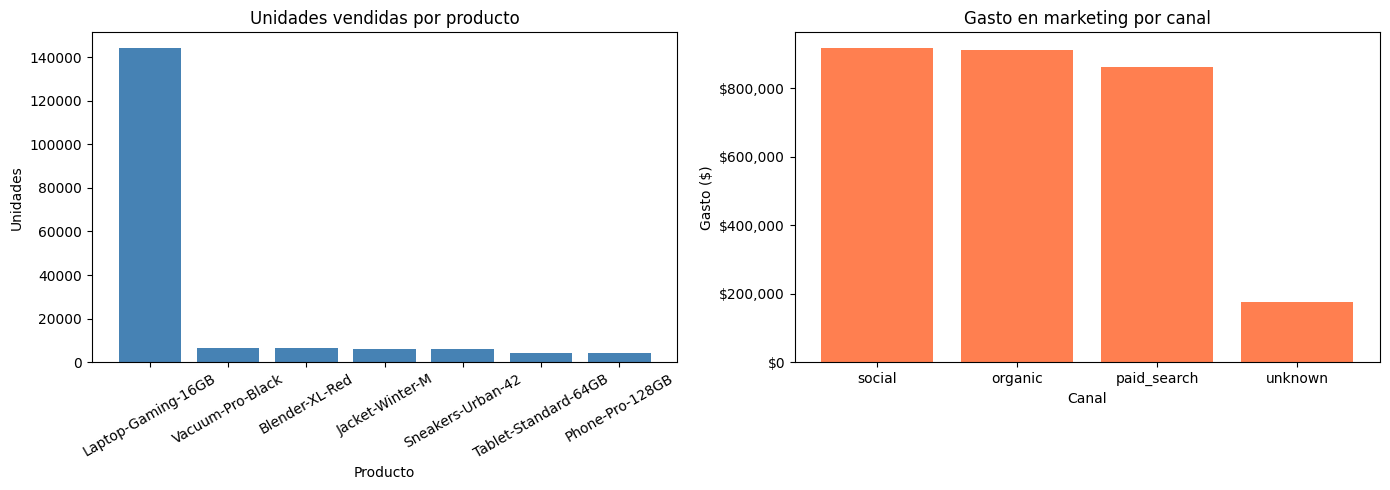

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventas por producto
ventas_plot = ventas_producto.drop('Unknown', errors='ignore')
axes[0].bar(ventas_plot.index, ventas_plot.values, color='steelblue')
axes[0].set_title('Unidades vendidas por producto')
axes[0].set_xlabel('Producto')
axes[0].set_ylabel('Unidades')
axes[0].tick_params(axis='x', rotation=30)

# Gasto por canal
axes[1].bar(gasto_canal['canal'], gasto_canal['gasto'], color='coral')
axes[1].set_title('Gasto en marketing por canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Gasto ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## Interpretacion

**Unidades vendidas por producto:**
Laptop-Gaming-16GB domina ampliamente las ventas con mas de 140,000 unidades vendidas,
muy por encima del resto de productos que se mantienen entre 4,000 y 6,500 unidades.
Esto indica una alta concentracion de ventas en un solo producto.

**Gasto en marketing por canal:**
El canal "unknown" representa una inversion menor (177K) que deberia investigarse para reclasificarse correctamente. 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 está muy bien el uso de gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos. Para complementar mejor estas visualizaciones te recomiendo siempre dejar tu interpretación en una celda markdown.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre procura dejar muy claro tu proceso de análisis redactando tus interpretaciones y demás en celdas markdown.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [12]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [13]:
# Explorar tabla events
# =========================
query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [14]:
# PARTE 1: Totales del funnel
# ======================
query_events = '''
SELECT *
FROM events
LIMIT 5;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [15]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit'       THEN 1
            WHEN 'select_item'       THEN 2
            WHEN 'add_to_cart'       THEN 3
            WHEN 'begin_checkout'    THEN 4
            WHEN 'add_payment_info'  THEN 5
            WHEN 'purchase'          THEN 6
        END AS orden_funnel
    FROM events
    GROUP BY nombre_evento
),
total_inicio AS (
    SELECT usuarios_unicos AS total FROM funnel WHERE nombre_evento = 'first_visit'
)
SELECT
    f.orden_funnel                                                              AS paso,
    f.nombre_evento,
    f.usuarios_unicos,
    ROUND(100.0 * f.usuarios_unicos / t.total, 2)                              AS tasa_conversion_pct
FROM funnel f, total_inicio t
WHERE f.orden_funnel IS NOT NULL
ORDER BY f.orden_funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,paso,nombre_evento,usuarios_unicos,tasa_conversion_pct
0,1,first_visit,7796,100.00
1,2,select_item,7582,97.26
2,3,add_to_cart,7634,97.92
3,4,begin_checkout,7208,92.46
4,5,add_payment_info,6250,80.17
5,6,purchase,6240,80.04


## Interpretacion del funnel de conversion

De los 7,796 usuarios que hicieron una primera visita, solo el 80% llego a completar una compra.

Los pasos con mayor abandono son:

- add_payment_info: es donde se pierde mas usuarios, bajando del 92.46% al 80.17%. 
  Esto sugiere friccion en el proceso de pago, como formularios complejos o falta de metodos de pago.

- begin_checkout: baja del 97.92% al 92.46%, indicando que algunos usuarios 
  abandonan justo antes de iniciar el checkout.

Recomendacion: priorizar la optimizacion del flujo de pago para reducir el abandono 
en add_payment_info, ya que representa la mayor oportunidad de mejora.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí te pediría revisar la lógica en la query ya que las conversiones **totales** para cada paso deberían ir bajando en % de forma descente pero si revisas tus porcentajes no están de forma descente así que hay que ajustar la query.

Además, en tus resultados tienes un `NaN` lo que indica que no se realizó de manera adecuada el cálculo de los porcentajes. Recuerda que los porcentajes deben ir de 0 a 100 (o de 0 a 1 dependiendo de cómo lo calcules) y no debería exceder esos límites.

También hace falta que redactes tu propio análisis de cada uno de los resultados que estás presentando, esto lo deberías hacer en una celda markdown.
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [16]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [17]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


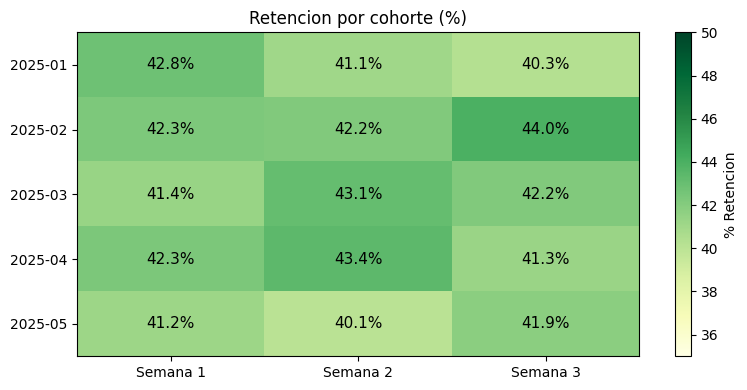

In [18]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        u.id_usuario,
        DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte_mes
    FROM users u
),
retenciones AS (
    SELECT
        c.id_usuario,
        c.cohorte_mes,
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 1  AND 7  AND ua.activo = 1 THEN 1 ELSE 0 END) AS retenido_w1,
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 8  AND 14 AND ua.activo = 1 THEN 1 ELSE 0 END) AS retenido_w2,
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 15 AND 21 AND ua.activo = 1 THEN 1 ELSE 0 END) AS retenido_w3
    FROM cohortes c
    LEFT JOIN user_activity ua ON c.id_usuario = ua.id_usuario
    GROUP BY c.id_usuario, c.cohorte_mes
)
SELECT
    cohorte_mes,
    COUNT(*)                                                          AS clientes_iniciales,
    SUM(retenido_w1)                                                  AS retenido_w1,
    SUM(retenido_w2)                                                  AS retenido_w2,
    SUM(retenido_w3)                                                  AS retenido_w3,
    ROUND(100.0 * SUM(retenido_w1) / NULLIF(COUNT(*), 0), 2)         AS semana_1,
    ROUND(100.0 * SUM(retenido_w2) / NULLIF(COUNT(*), 0), 2)         AS semana_2,
    ROUND(100.0 * SUM(retenido_w3) / NULLIF(COUNT(*), 0), 2)         AS semana_3
FROM retenciones
GROUP BY cohorte_mes
ORDER BY cohorte_mes;
'''

cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

import matplotlib.pyplot as plt
import numpy as np

# Preparar datos
cohorte_plot = cohorte_final[['cohorte_mes', 'semana_1', 'semana_2', 'semana_3']].copy()
cohorte_plot['cohorte_mes'] = cohorte_plot['cohorte_mes'].dt.strftime('%Y-%m')
cohorte_plot = cohorte_plot.set_index('cohorte_mes')

# Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(cohorte_plot.values, cmap='YlGn', aspect='auto', vmin=35, vmax=50)

ax.set_xticks(range(3))
ax.set_xticklabels(['Semana 1', 'Semana 2', 'Semana 3'])
ax.set_yticks(range(len(cohorte_plot)))
ax.set_yticklabels(cohorte_plot.index)
ax.set_title('Retencion por cohorte (%)')

for i in range(len(cohorte_plot)):
    for j in range(3):
        ax.text(j, i, f'{cohorte_plot.values[i, j]:.1f}%', ha='center', va='center', fontsize=11)

plt.colorbar(im, ax=ax, label='% Retencion')
plt.tight_layout()
plt.show()

## Interpretacion de retencion por cohortes

La retencion se mantiene estable entre 40% y 44% en todas las cohortes y semanas,
lo que indica un comportamiento consistente de los usuarios.

Sin embargo, la retencion baja del registro inicial a la semana 1, 
lo que sugiere que los usuarios que no regresan en la primera semana 
tienden a no volver. Se recomienda implementar estrategias de reactivacion
temprana como notificaciones o descuentos en los primeros 7 dias.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto la query y los resultados presentados. Lo único que recomendaría aquí es tratar de llevarlo a algo más visual para que sea más fácil de explicar y entender
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversion del grupo control es igual a la del grupo tratamiento. El cambio en la UI no tiene efecto.
   - **H₁ (Hipótesis alternativa):** La tasa de conversion del grupo control es diferente a la del grupo tratamiento. El cambio en la UI si tiene efecto.
   
**Test estadístico:** Test Z de diferencia de proporciones (two-sided)
**Nivel de significancia alpha:** 0.05

In [19]:
exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

print('Shape:', exp.shape)
display(exp.head())
print('\nDistribucion de variantes:')
print(exp['variante'].value_counts())
print('\nTasa de conversion general:', exp['convirtio'].mean().round(4))


Shape: (10000, 7)


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



Distribucion de variantes:
tratamiento    5035
control        4965
Name: variante, dtype: int64

Tasa de conversion general: 0.1599


In [20]:
control     = exp[exp['variante'] == 'control']['convirtio']
tratamiento = exp[exp['variante'] == 'tratamiento']['convirtio']

n_ctrl    = len(control)
n_trt     = len(tratamiento)
conv_ctrl = control.mean()
conv_trt  = tratamiento.mean()

print(f'Grupo control:     n={n_ctrl:,}, tasa de conversion={conv_ctrl:.4f} ({conv_ctrl*100:.2f}%)')
print(f'Grupo tratamiento: n={n_trt:,}, tasa de conversion={conv_trt:.4f} ({conv_trt*100:.2f}%)')
print(f'Diferencia absoluta: {(conv_trt - conv_ctrl)*100:.2f} pp')

Grupo control:     n=4,965, tasa de conversion=0.1569 (15.69%)
Grupo tratamiento: n=5,035, tasa de conversion=0.1629 (16.29%)
Diferencia absoluta: 0.60 pp


In [21]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

count  = np.array([control.sum(), tratamiento.sum()])
nobs   = np.array([n_ctrl, n_trt])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

alpha = 0.05

print('RESULTADO DEL TEST ESTADISTICO')
print('=' * 45)
print(f'Z-statistic:  {z_stat:.4f}')
print(f'p-value:      {p_value:.4f}')
print(f'Alpha:        {alpha}')
print()
if p_value < alpha:
    print('Se RECHAZA H0.')
    print('El cambio en la UI tiene un efecto estadisticamente significativo.')
else:
    print('No se rechaza H0 (p-value > alpha).')
    print('No hay evidencia suficiente de que el cambio en la UI impacte la conversion.')
    print(f'La diferencia de {(conv_trt-conv_ctrl)*100:.2f} pp puede deberse al azar.')

RESULTADO DEL TEST ESTADISTICO
Z-statistic:  -0.8133
p-value:      0.4161
Alpha:        0.05

No se rechaza H0 (p-value > alpha).
No hay evidencia suficiente de que el cambio en la UI impacte la conversion.
La diferencia de 0.60 pp puede deberse al azar.


## Interpretacion del test A/B

Se evaluo si la nueva interfaz de checkout (grupo tratamiento) mejora la tasa de conversion
respecto al diseno actual (grupo control).

- Tasa de conversion control:     15.69%
- Tasa de conversion tratamiento: 16.29%
- Diferencia:                     +0.60 puntos porcentuales

El test Z arrojo un p-value de 0.4161, muy por encima del nivel de significancia de 0.05.
**No se rechaza H0**: la diferencia observada de 0.60 pp no es estadisticamente significativa
y puede atribuirse al azar.

Conclusion: no hay evidencia suficiente para implementar el nuevo diseno de checkout.
Se recomienda iterar el diseno con cambios mas sustanciales o aumentar el tamano de muestra
antes de tomar una decision definitiva.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## Conclusiones y Recomendaciones Generales

### Conclusiones

**Rentabilidad:** RappiPlus es un negocio rentable con un Revenue de 51.97M y un Profit de 5.97M (margen del 11.5%). Sin embargo, el costo de producto representa el 83% del revenue, lo que deja poco margen de maniobra ante variaciones de demanda o costos.

**Embudo de conversion:**
De los 7,796 usuarios que realizaron una primera visita, el 80% completo una compra.
La mayor caida ocurre en add_payment_info (del 92.46% al 80.17%), lo que indica
friccion en el proceso de pago como principal punto de abandono.

**Retencion por cohortes:**
La retencion se mantiene estable entre 40% y 44% en todas las cohortes y semanas,
indicando un comportamiento consistente. Sin embargo, se pierde mas del 55% de usuarios
antes de la semana 1, lo que sugiere que el primer contacto es critico.

**Test A/B:**
La nueva UI de checkout no mostro un impacto estadisticamente significativo (p=0.4161).
No hay evidencia para implementar el cambio en produccion con los datos actuales.

---

### Recomendaciones

1. **Optimizar el flujo de pago:** Simplificar el formulario de add_payment_info y agregar
   mas metodos de pago para reducir el abandono en ese paso del funnel.

2. **Programa de reactivacion temprana:** Implementar notificaciones o descuentos
   dirigidos a usuarios nuevos en sus primeros 7 dias para mejorar la retencion en semana 1.

3. **Diversificar el catalogo de productos:** La dependencia de Laptop-Gaming-16GB
   como producto dominante representa un riesgo. Promover otros productos puede
   distribuir mejor el riesgo y aumentar el ticket promedio.

4. **Reclasificar canal "unknown" en marketing:** Los $177K sin clasificar deben auditarse
   para evaluar correctamente el ROI por canal.

5. **Iterar el test A/B:** Redisenar la prueba con cambios mas sustanciales en la UI
   o aumentar el tamano de muestra para detectar diferencias menores con mas poder estadistico.

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

https://drive.google.com/drive/folders/1JduLOObo_ulUoOYnP-UXZ0eZcj8aOVh4?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Laura, pero hace falta la parte de story telling que cómo profesional de datos siempre se debe tener. Es decir, usando celdas markdown se debe ir redactando el análisis que vas realizando de los diferentes resultados y de esta forma comunicar de manera adecuada que es lo que se está analizando y por qué.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Jesus!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>